In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2

In [18]:
def clean_invalid_images(directory):
    """Remove corrupted or invalid images from dataset"""
    removed = 0
    for folder in os.listdir(directory):
        folder_path = os.path.join(directory, folder)
        if not os.path.isdir(folder_path):
            continue
        for file in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file)
            try:
                img = cv2.imread(file_path)
                if img is None:
                    os.remove(file_path)
                    removed += 1
                    print(f"❌ Invalid image removed: {file_path}")
            except:
                os.remove(file_path)
                removed += 1
                print(f"⚠️ Problem reading: {file_path}")
    print(f"\n🧹 Cleanup Done! Removed {removed} invalid images.\n")

# Run cleanup on both train and test folders
clean_invalid_images(r"E:\GitHub\PSTU_Academic\Level 3 Semester 1(5th Semester)\CIT 316 - Artificial Intelligence Sessional\CNN\train")
clean_invalid_images(r"E:\GitHub\PSTU_Academic\Level 3 Semester 1(5th Semester)\CIT 316 - Artificial Intelligence Sessional\CNN\test")


🧹 Cleanup Done! Removed 0 invalid images.


🧹 Cleanup Done! Removed 0 invalid images.



In [19]:
# Load training data
train_ds = tf.keras.utils.image_dataset_from_directory(
    r"E:\GitHub\PSTU_Academic\Level 3 Semester 1(5th Semester)\CIT 316 - Artificial Intelligence Sessional\CNN\train",
    image_size=(256, 256),
    batch_size=32
)

# Load test data
test_ds = tf.keras.utils.image_dataset_from_directory(
    r"E:\GitHub\PSTU_Academic\Level 3 Semester 1(5th Semester)\CIT 316 - Artificial Intelligence Sessional\CNN\test",
    image_size=(256, 256),
    batch_size=32
)

# Get class names
class_names = train_ds.class_names
print("Detected Classes:", class_names)

Found 965 files belonging to 2 classes.
Found 1005 files belonging to 2 classes.
Detected Classes: ['cats', 'dogs']


In [20]:
# Normalize images (0-255 → 0-1)
train_ds = train_ds.map(lambda x, y: (x / 255.0, y))
test_ds = test_ds.map(lambda x, y: (x / 255.0, y))

# Improve performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("✅ Data normalized and optimized!")

✅ Data normalized and optimized!


In [21]:
model = models.Sequential([
    layers.Input(shape=(256, 256, 3)),
    
    # Conv Block 1
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    
    # Conv Block 2
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    
    # Conv Block 3
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    
    # Dense Layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,839,234 (56.61 MB)

 Trainable params: 14,839,234 (56.61 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=30
)

Epoch 1/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 30s 919ms/step - accuracy: 0.5741 - loss: 1.5416 - val_accuracy: 0.5940 - val_loss: 0.6746
Epoch 2/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 29s 952ms/step - accuracy: 0.5927 - loss: 0.6739 - val_accuracy: 0.6060 - val_loss: 0.6584
Epoch 3/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.6083 - loss: 0.6541 - val_accuracy: 0.6000 - val_loss: 0.6555
Epoch 4/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.6560 - loss: 0.6211 - val_accuracy: 0.6299 - val_loss: 0.6227
Epoch 5/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.6953 - loss: 0.5585 - val_accuracy: 0.7423 - val_loss: 0.4989
Epoch 6/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.7938 - loss: 0.4486 - val_accuracy: 0.8517 - val_loss: 0.3547
Epoch 7/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.8187 - loss: 0.3879 - val_accuracy: 0.8438 - val_loss: 0.3347
Epoch 8/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.8933 - loss: 0.2704 - val_accuracy: 0.9174 - val

In [24]:
loss, accuracy = model.evaluate(test_ds)
print(f"\n✅ Test Accuracy: {accuracy*100:.2f}%")
print(f"✅ Test Loss: {loss:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 258ms/step - accuracy: 0.9861 - loss: 0.1577

✅ Test Accuracy: 98.61%
✅ Test Loss: 0.1577


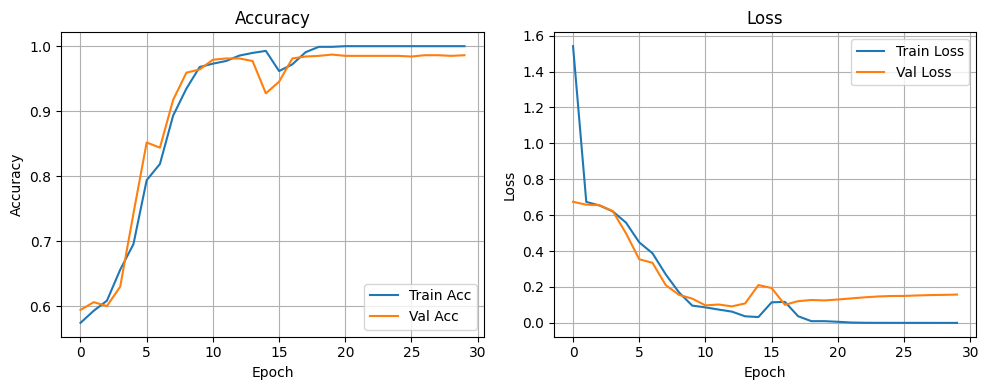

In [25]:
plt.figure(figsize=(10, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [29]:
def predict_image(img_path):
    """Predict class for a single image"""
    
    if not os.path.exists(img_path):
        print(f"❌ File not found: {img_path}")
        return

    # Load image
    img = cv2.imread(img_path)
    if img is None:
        print(f"❌ Cannot read image: {img_path}")
        return

    # Convert to RGB and display
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f"Testing: {os.path.basename(img_path)}")
    plt.axis('off')
    plt.show()

    # Preprocess and predict
    img_resized = cv2.resize(img, (256, 256))
    img_input = img_resized.reshape((1, 256, 256, 3)) / 255.0

    prediction = model.predict(img_input, verbose=0)
    predicted_class = class_names[np.argmax(prediction[0])]
    confidence = np.max(prediction[0]) * 100

    print(f"\n🖼️ Predicted: {predicted_class}")
    print(f"✅ Confidence: {confidence:.2f}%")

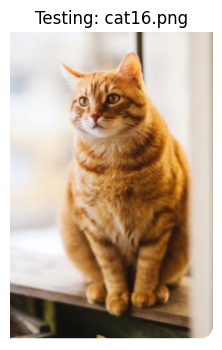


🖼️ Predicted: dogs
✅ Confidence: 96.45%


In [28]:
cat_path = r"E:\GitHub\PSTU_Academic\Level 3 Semester 1(5th Semester)\CIT 316 - Artificial Intelligence Sessional\CNN\cat16.png"
predict_image(cat_path)

In [ ]:
dog_path = r"E:\GitHub\PSTU_Academic\Level 3 Semester 1(5th Semester)\CIT 316 - Artificial Intelligence Sessional\CNN\dog16.png"
predict_image(dog_path)